In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

[ 60.  57.  52. ...  -2. -18.  -9.]
[88. 80. 76. ... 49. 60. 86.]
[51. 42. 43. ... 24.  5. 19.]
[45. 73. 93. ... 41. 44. 59.]
[ 37.  84. 112. ...  -2.  25.  38.]
[27. 38. 28. ... 33. 40. 28.]
[54. 65. 54. ... 48. 36. 21.]
[60. 80. 58. ...  0. -3.  0.]
[72. 71. 69. ... 18. 21. 21.]
Mảng trung bình: [54.88888889 65.55555556 65.         ... 23.22222222 23.33333333
 29.22222222]


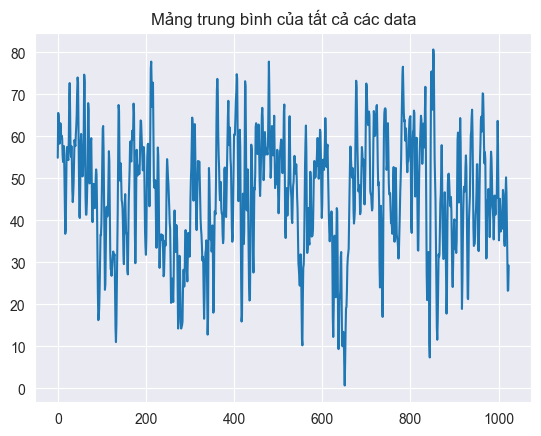

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Danh sách để lưu tất cả các data
all_data = []

for i in range(1, 10):
    data = np.loadtxt(fr"D:\Tuda\Data4life\Data\tuda_real\{i}.txt")
    print(data)
    # plt.plot(data)
    # plt.show()
    
    # Thêm data vào danh sách all_data
    all_data.append(data)

# Chuyển danh sách thành mảng NumPy để dễ tính toán
all_data = np.array(all_data)

# Tính trung bình theo từng phần tử (theo chiều dọc, axis=0)
average_array = np.mean(all_data, axis=0)

# In mảng trung bình
print("Mảng trung bình:", average_array)

# Vẽ mảng trung bình
plt.plot(average_array)
plt.title("Mảng trung bình của tất cả các data")
plt.show()


In [19]:
import os
import numpy as np
import pandas as pd

# Thư mục chính chứa tất cả các thư mục con
main_dir = r"D:\Tuda\Data4life\Data"

# Danh sách để lưu DataFrame từ tất cả các thư mục
all_dataframes = []

# Duyệt qua tất cả các thư mục con trong main_dir
for subdir in os.listdir(main_dir):
    subdir_path = os.path.join(main_dir, subdir)
    
    # Kiểm tra nếu subdir_path là một thư mục
    if os.path.isdir(subdir_path):
        print(f"Đang xử lý thư mục: {subdir_path}")
        
        # Đọc file results.txt trong thư mục hiện tại để lấy nhãn
        results_file = os.path.join(subdir_path, 'results.txt')
        with open(results_file, 'r') as file:
            lines = file.readlines()

        # Mảng để lưu nhãn
        labels = []
        for line in lines:
            # Nếu dòng chứa 'image3', gán nhãn là 1, ngược lại là 0
            if 'image3' in line:
                labels.append(1)
            else:
                labels.append(0)

        # Đọc dữ liệu từ các file txt và lưu vào DataFrame
        data_list = []
        for i in range(1, 30):
            txt_file = os.path.join(subdir_path, f'{i}.txt')
            if os.path.exists(txt_file):
                data = np.loadtxt(txt_file)
                data_list.append(data)

        # Tạo DataFrame từ danh sách các dữ liệu
        df_data = pd.DataFrame(data_list)

        # Thêm cột nhãn (labels) vào DataFrame
        df_data['Label'] = labels[:len(df_data)]

        # Thêm tên thư mục để phân biệt (nếu cần)
        df_data['Folder'] = subdir

        # Thêm DataFrame vào danh sách all_dataframes
        all_dataframes.append(df_data)

# Gộp tất cả các DataFrame thành một DataFrame duy nhất
final_df = pd.concat(all_dataframes, ignore_index=True)

# Hiển thị DataFrame cuối cùng
print(final_df)


Đang xử lý thư mục: D:\Tuda\Data4life\Data\duc
Đang xử lý thư mục: D:\Tuda\Data4life\Data\Minh
Đang xử lý thư mục: D:\Tuda\Data4life\Data\Phuc
Đang xử lý thư mục: D:\Tuda\Data4life\Data\tuda_real
Đang xử lý thư mục: D:\Tuda\Data4life\Data\Vu
         0      1      2      3      4      5      6      7      8      9  \
0     26.0   16.0   19.0   34.0   41.0   43.0   33.0   20.0   19.0   28.0   
1     39.0   43.0   49.0   51.0   39.0   22.0   19.0   20.0   20.0   25.0   
2     28.0   32.0   33.0   36.0   32.0   20.0   11.0    8.0    7.0    8.0   
3    121.0  128.0  124.0  123.0  123.0  119.0  115.0  116.0  113.0  104.0   
4     56.0   37.0   26.0   32.0   40.0   43.0   42.0   38.0   28.0   27.0   
..     ...    ...    ...    ...    ...    ...    ...    ...    ...    ...   
132   76.0   64.0   76.0  102.0  112.0  101.0   87.0   66.0   43.0   48.0   
133   74.0   72.0   75.0   96.0  112.0  108.0   99.0   96.0   90.0   89.0   
134   65.0   52.0   33.0   20.0   32.0   58.0   70.0   60.0   58.

In [16]:
len(final_df)

137

In [21]:
final_df.to_csv("test.csv", index=False)